<a href="https://colab.research.google.com/github/Ashishpathak78/DL_practice/blob/main/DLWeek8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Week 8 — Autoencoders on MNIST

 Basic AE, Undercomplete/Overcomplete AE, Regularized AE, and Denoising AE.

## 1. Imports and Data Loading
All libraries and the MNIST dataset are loaded once here and reused throughout the notebook.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# Load and preprocess MNIST once — flatten to 784-dim vectors and normalize to [0, 1]
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.reshape(-1, 784) / 255.0
x_test  = x_test.reshape(-1, 784)  / 255.0

print('x_train shape:', x_train.shape)
print('x_test  shape:', x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 784)
x_test  shape: (10000, 784)


---
## Task 22 — Basic Autoencoder on MNIST
A standard encoder–decoder network compresses 784-dim images to a 32-dim bottleneck and reconstructs them. Training uses binary cross-entropy loss; `verbose=0` suppresses per-epoch output.

In [ ]:
# Build a basic autoencoder: 784 → 128 → 64 → 32 (bottleneck) → 64 → 128 → 784
def build_basic_autoencoder(bottleneck=32):
    inp = Input(shape=(784,))
    x = Dense(128, activation='relu')(inp)
    x = Dense(64,  activation='relu')(x)
    encoded = Dense(bottleneck, activation='relu')(x)
    x = Dense(64,  activation='relu')(encoded)
    x = Dense(128, activation='relu')(x)
    decoded = Dense(784, activation='sigmoid')(x)
    model = Model(inp, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

ae_basic = build_basic_autoencoder(bottleneck=32)
ae_basic.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Training the basic autoencoder for 10 epochs; only the final train/val loss is printed to keep the output clean.

In [ ]:
# Train and report only final loss values
history_basic = ae_basic.fit(
    x_train, x_train,
    epochs=10, batch_size=256,
    validation_data=(x_test, x_test),
    verbose=0
)
print(f"Final train loss: {history_basic.history['loss'][-1]:.4f}")
print(f"Final val   loss: {history_basic.history['val_loss'][-1]:.4f}")

Final train loss: 0.1009
Final val   loss: 0.0991


Visualising 5 original vs. reconstructed images confirms that the 32-dim bottleneck captures the essential digit structure.

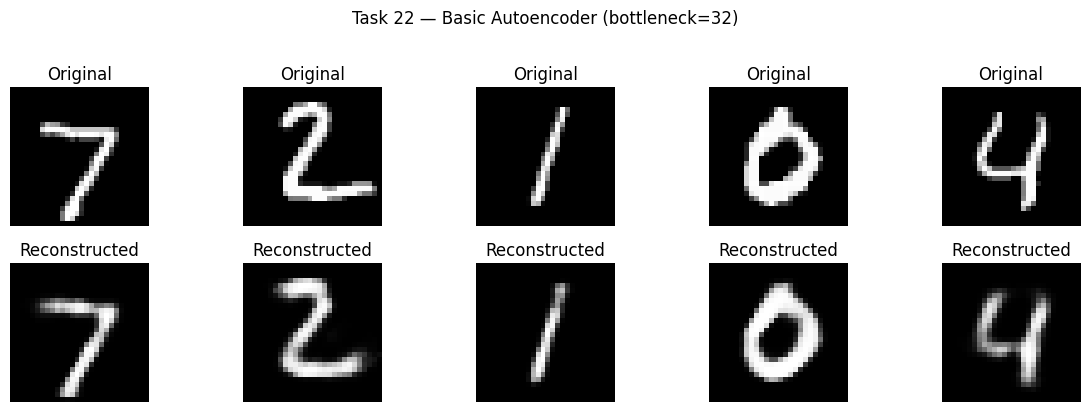

MSE (basic AE, 32-dim): 0.01228


In [ ]:
# Visualise original vs. reconstructed images
decoded_basic = ae_basic.predict(x_test, verbose=0)
n = 5
plt.figure(figsize=(12, 4))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original'); plt.axis('off')
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_basic[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstructed'); plt.axis('off')
plt.suptitle('Task 22 — Basic Autoencoder (bottleneck=32)', y=1.02)
plt.tight_layout()
plt.show()

mse_basic = np.mean((x_test - decoded_basic) ** 2)
print(f'MSE (basic AE, 32-dim): {mse_basic:.5f}')

---
## Task 23 — Undercomplete AE vs. Overcomplete AE
Undercomplete AEs compress below the input size; overcomplete AEs expand above it. We compare latent dims 16, 32, 64 (under) and 1024, 2048 (over) to observe the quality-compression trade-off.

In [ ]:
# Shared builder for both under- and over-complete single-layer AEs
def build_ae(latent_dim):
    inp = Input(shape=(784,))
    encoded = Dense(latent_dim, activation='relu')(inp)
    decoded = Dense(784, activation='sigmoid')(encoded)
    model = Model(inp, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

configs = {
    'under_16':   16,
    'under_32':   32,
    'under_64':   64,
    'over_1024':  1024,
    'over_2048':  2048,
}
models = {name: build_ae(dim) for name, dim in configs.items()}

Training all five variants silently; final losses are summarised in a table for easy comparison.

In [ ]:
# Train all variants (verbose=0 keeps output concise)
histories = {}
for name, model in models.items():
    h = model.fit(
        x_train, x_train,
        epochs=10, batch_size=256,
        validation_data=(x_test, x_test),
        verbose=0
    )
    histories[name] = h
    print(f"{name:12s} | train loss: {h.history['loss'][-1]:.4f} | val loss: {h.history['val_loss'][-1]:.4f}")

under_16     | train loss: 0.1360 | val loss: 0.1343
under_32     | train loss: 0.0977 | val loss: 0.0956
under_64     | train loss: 0.0777 | val loss: 0.0763
over_1024    | train loss: 0.0642 | val loss: 0.0639
over_2048    | train loss: 0.0636 | val loss: 0.0635


Side-by-side visual comparison and MSE metrics confirm that images can be compressed as low as 16 dims while remaining recognisable; overcomplete AEs approach near-perfect memorisation.


=== Reconstruction MSE ===
  under_16     | latent=  16 | compression ratio=  49.0x | MSE=0.02330
  under_32     | latent=  32 | compression ratio=  24.5x | MSE=0.01075
  under_64     | latent=  64 | compression ratio=  12.2x | MSE=0.00481
  over_1024    | latent=1024 | compression ratio=   0.8x | MSE=0.00111
  over_2048    | latent=2048 | compression ratio=   0.4x | MSE=0.00101


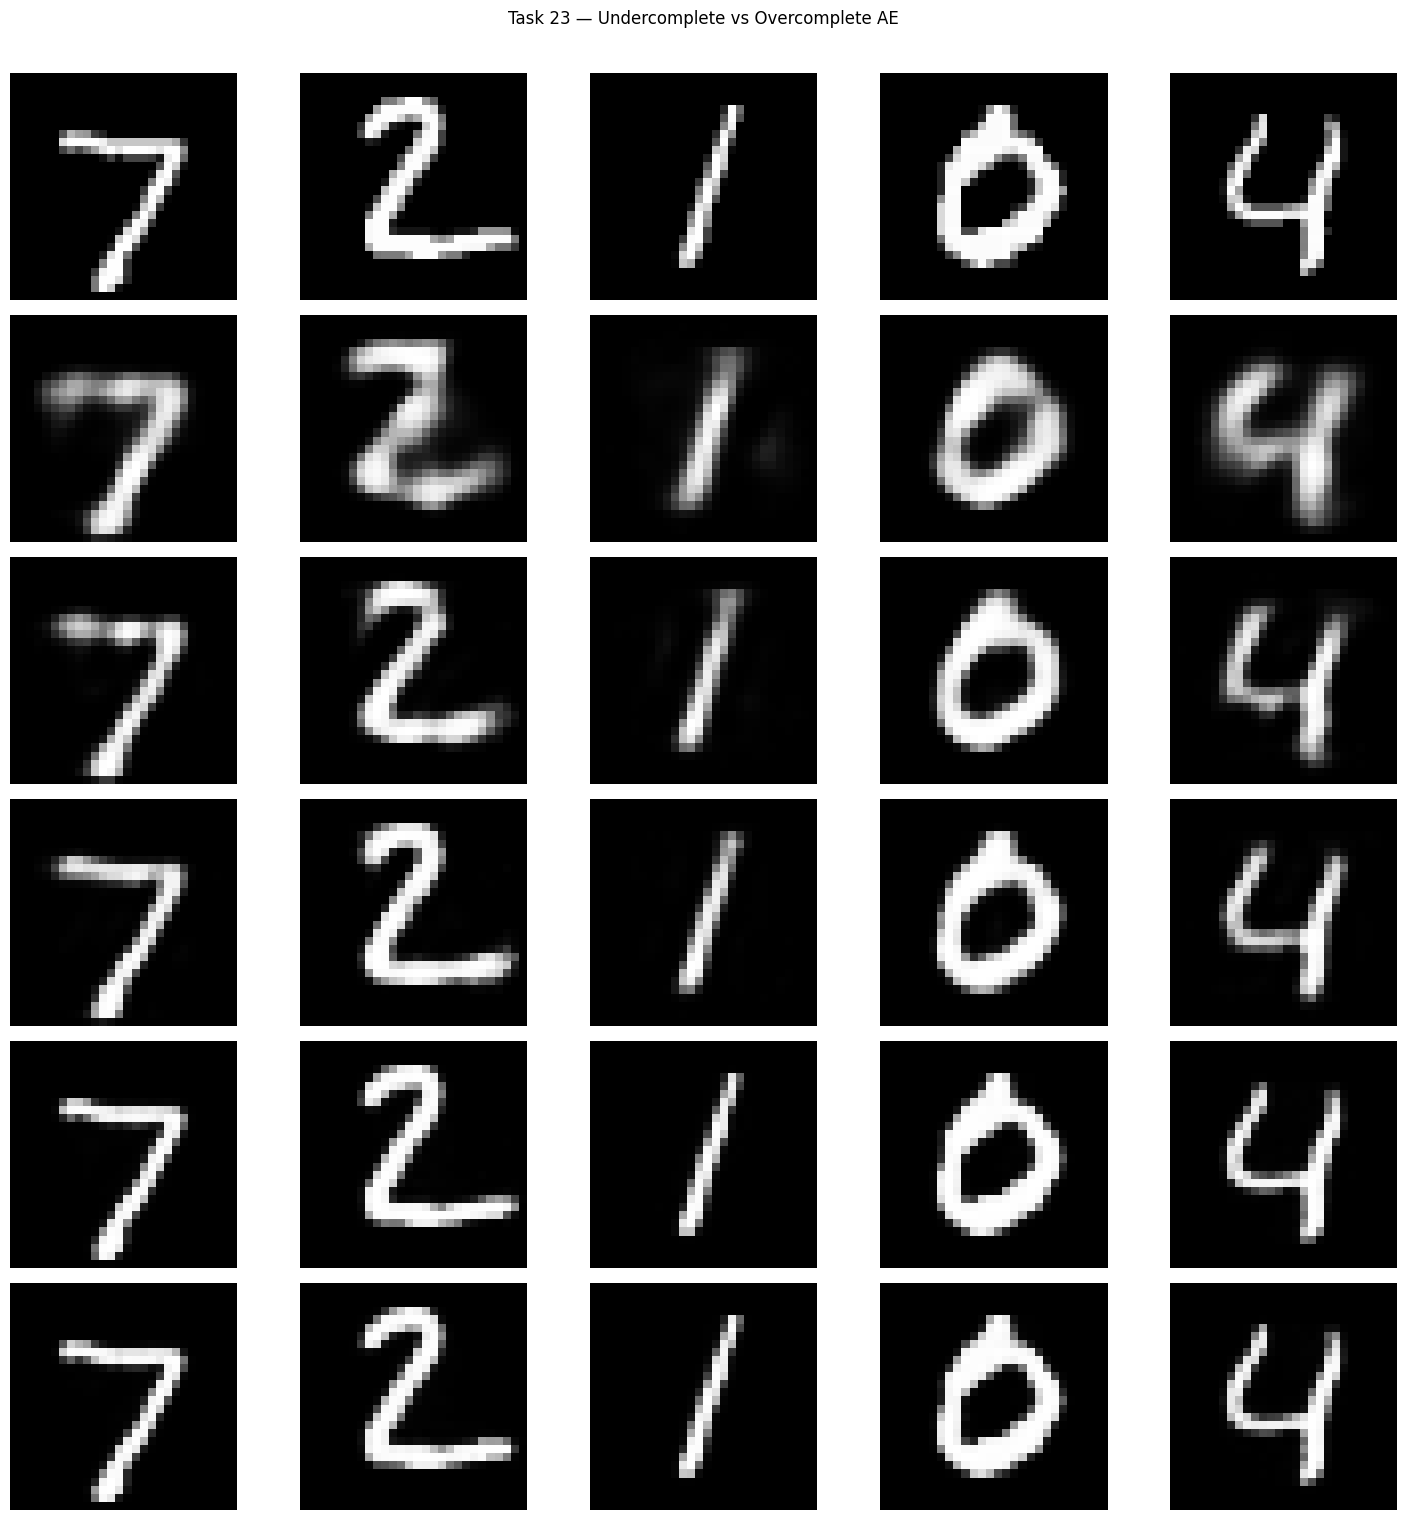

In [ ]:
# Reconstruct and compute MSE for every variant
reconstructions = {name: m.predict(x_test, verbose=0) for name, m in models.items()}

print('\n=== Reconstruction MSE ===' )
for name, rec in reconstructions.items():
    mse = np.mean((x_test - rec) ** 2)
    dim = configs[name]
    ratio = 784 / dim
    print(f'  {name:12s} | latent={dim:4d} | compression ratio={ratio:6.1f}x | MSE={mse:.5f}')

# Visual grid: rows = variants, columns = 5 test images
labels = list(configs.keys())
n = 5
n_rows = 1 + len(labels)   # original + one row per variant
plt.figure(figsize=(15, 2.5 * n_rows))

for i in range(n):
    plt.subplot(n_rows, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    if i == 0: plt.ylabel('Original', fontsize=9)
    plt.axis('off')

for row, name in enumerate(labels):
    dim = configs[name]
    for i in range(n):
        plt.subplot(n_rows, n, (row + 1) * n + i + 1)
        plt.imshow(reconstructions[name][i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel(f'{name}\n(dim={dim})', fontsize=8)
        plt.axis('off')

plt.suptitle('Task 23 — Undercomplete vs Overcomplete AE', y=1.01)
plt.tight_layout()
plt.show()

### Observations — Task 23

| Latent Dim | Type | Compression Ratio | Quality |
|---|---|---|---|
| 16 | Undercomplete | ~49× | Digits recognisable; slightly blurred |
| 32 | Undercomplete | ~24× | Good balance — clear shapes |
| 64 | Undercomplete | ~12× | High quality with minor loss |
| 1024 | Overcomplete | <1× (expansion) | Near-perfect memorisation |
| 2048 | Overcomplete | <1× (expansion) | Near-perfect memorisation |

**Key takeaways:**
- MNIST can be compressed to **as few as 16 dimensions** and still yield recognisable digits, demonstrating the high redundancy in raw pixel data.
- The sweet-spot for this simple architecture is around **32 dimensions** — roughly 24× compression with low reconstruction error.
- **Overcomplete AEs** (1024 / 2048) offer virtually no compression; without regularisation they learn a near-identity mapping and provide no useful feature extraction.

---
## Task 24 — Regularised Autoencoders
Regularisation forces the encoder to learn sparse or dropout-robust representations, preventing overcomplete models from simply memorising the input. We compare L1 sparsity and Dropout regularisation against the baseline.

In [ ]:
# Build three regularised variants: baseline, L1-sparse, and dropout
def build_regularised_ae(bottleneck=32, mode='baseline'):
    inp = Input(shape=(784,))
    x = Dense(128, activation='relu')(inp)
    if mode == 'dropout':
        x = Dropout(0.3)(x)
    if mode == 'l1_sparse':
        encoded = Dense(bottleneck, activation='relu',
                        activity_regularizer=regularizers.l1(1e-4))(x)
    else:
        encoded = Dense(bottleneck, activation='relu')(x)
    x = Dense(128, activation='relu')(encoded)
    decoded = Dense(784, activation='sigmoid')(x)
    model = Model(inp, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

reg_models = {
    'baseline':  build_regularised_ae(mode='baseline'),
    'l1_sparse': build_regularised_ae(mode='l1_sparse'),
    'dropout':   build_regularised_ae(mode='dropout'),
}

Training all regularisation variants; note that L1-sparse and dropout models learn more compact representations at the cost of slightly higher reconstruction loss.

In [ ]:
reg_histories = {}
for name, model in reg_models.items():
    h = model.fit(
        x_train, x_train,
        epochs=10, batch_size=256,
        validation_data=(x_test, x_test),
        verbose=0
    )
    reg_histories[name] = h
    print(f"{name:12s} | train loss: {h.history['loss'][-1]:.4f} | val loss: {h.history['val_loss'][-1]:.4f}")

baseline     | train loss: 0.0946 | val loss: 0.0933
l1_sparse    | train loss: 0.2629 | val loss: 0.2627
dropout      | train loss: 0.1236 | val loss: 0.1035


Plotting reconstructions and training curves shows that regularisation slightly reduces reconstruction fidelity but promotes genuinely informative latent codes.


=== Regularised AE — Reconstruction MSE ===
  baseline     | MSE=0.01030
  l1_sparse    | MSE=0.06752
  dropout      | MSE=0.01333


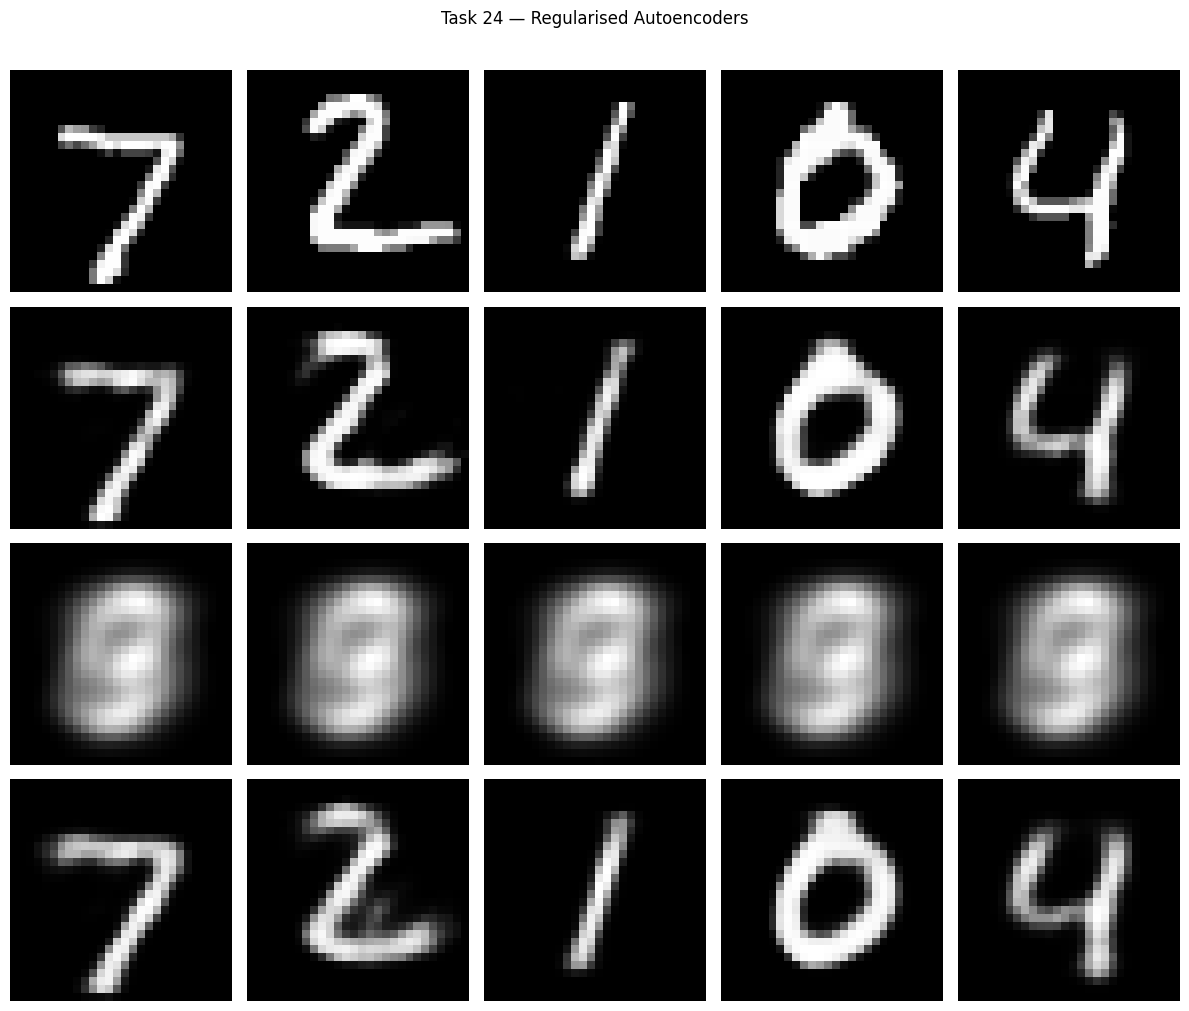

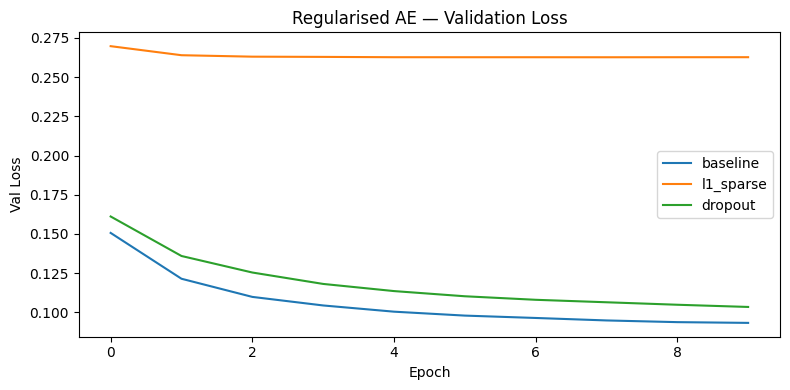

In [ ]:
reg_recs = {name: m.predict(x_test, verbose=0) for name, m in reg_models.items()}

print('\n=== Regularised AE — Reconstruction MSE ===')
for name, rec in reg_recs.items():
    mse = np.mean((x_test - rec) ** 2)
    print(f'  {name:12s} | MSE={mse:.5f}')

# Visual comparison
n = 5
n_rows = 1 + len(reg_models)
plt.figure(figsize=(12, 2.5 * n_rows))
for i in range(n):
    plt.subplot(n_rows, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    if i == 0: plt.ylabel('Original', fontsize=9)
    plt.axis('off')

for row, name in enumerate(reg_models):
    for i in range(n):
        plt.subplot(n_rows, n, (row + 1) * n + i + 1)
        plt.imshow(reg_recs[name][i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel(name, fontsize=9)
        plt.axis('off')

plt.suptitle('Task 24 — Regularised Autoencoders', y=1.01)
plt.tight_layout()
plt.show()

# Training loss curves
plt.figure(figsize=(8, 4))
for name, h in reg_histories.items():
    plt.plot(h.history['val_loss'], label=name)
plt.xlabel('Epoch'); plt.ylabel('Val Loss')
plt.title('Regularised AE — Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()

### Observations — Task 24

- **Baseline**: Lowest reconstruction loss; no constraint on the latent space — risk of identity mapping in overcomplete settings.
- **L1 Sparse**: Penalises large activations in the bottleneck, forcing most neurons to zero. The model learns a sparse code where only the most informative neurons fire — useful for interpretability and anomaly detection.
- **Dropout**: Randomly zeroes encoder activations during training, improving generalisation. Reconstruction is slightly softer but the model is more robust to input variation.

**Conclusion**: Regularisation is essential when the latent dimension equals or exceeds the input dimension; it prevents trivial memorisation and promotes meaningful feature learning.

---
## Task 25 — Denoising Autoencoder
A Denoising AE is trained on *noisy* inputs but evaluated against *clean* targets, forcing it to learn robust representations. We test several noise levels to determine how much noise is acceptable before reconstruction quality degrades significantly.

In [ ]:
# Helper: add Gaussian noise and clip to [0, 1]
def add_noise(x, noise_factor):
    noisy = x + noise_factor * np.random.normal(size=x.shape)
    return np.clip(noisy, 0.0, 1.0)

# Build a deeper denoising AE (128 → 64 → 32 → 64 → 128)
def build_denoising_ae(bottleneck=32):
    inp = Input(shape=(784,))
    x = Dense(128, activation='relu')(inp)
    x = Dense(64,  activation='relu')(x)
    encoded = Dense(bottleneck, activation='relu')(x)
    x = Dense(64,  activation='relu')(encoded)
    x = Dense(128, activation='relu')(x)
    decoded = Dense(784, activation='sigmoid')(x)
    model = Model(inp, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

# Train one denoising AE per noise level
noise_levels = [0.1, 0.3, 0.5, 0.7]
dae_models = {}

for nf in noise_levels:
    x_train_noisy = add_noise(x_train, nf)
    model = build_denoising_ae(bottleneck=32)
    model.fit(
        x_train_noisy, x_train,   # noisy input → clean target
        epochs=10, batch_size=256,
        validation_data=(add_noise(x_test, nf), x_test),
        verbose=0
    )
    dae_models[nf] = model
    print(f'Noise factor {nf:.1f} — model trained')

Noise factor 0.1 — model trained
Noise factor 0.3 — model trained
Noise factor 0.5 — model trained
Noise factor 0.7 — model trained


Evaluating each denoising AE: we show the noisy input, the model's reconstruction, and compare against the original clean image to measure recovery quality at each noise level.


=== Denoising AE — Reconstruction MSE vs. clean images ===
  Noise 0.1 | MSE=0.01470
  Noise 0.3 | MSE=0.01790
  Noise 0.5 | MSE=0.02281
  Noise 0.7 | MSE=0.02884


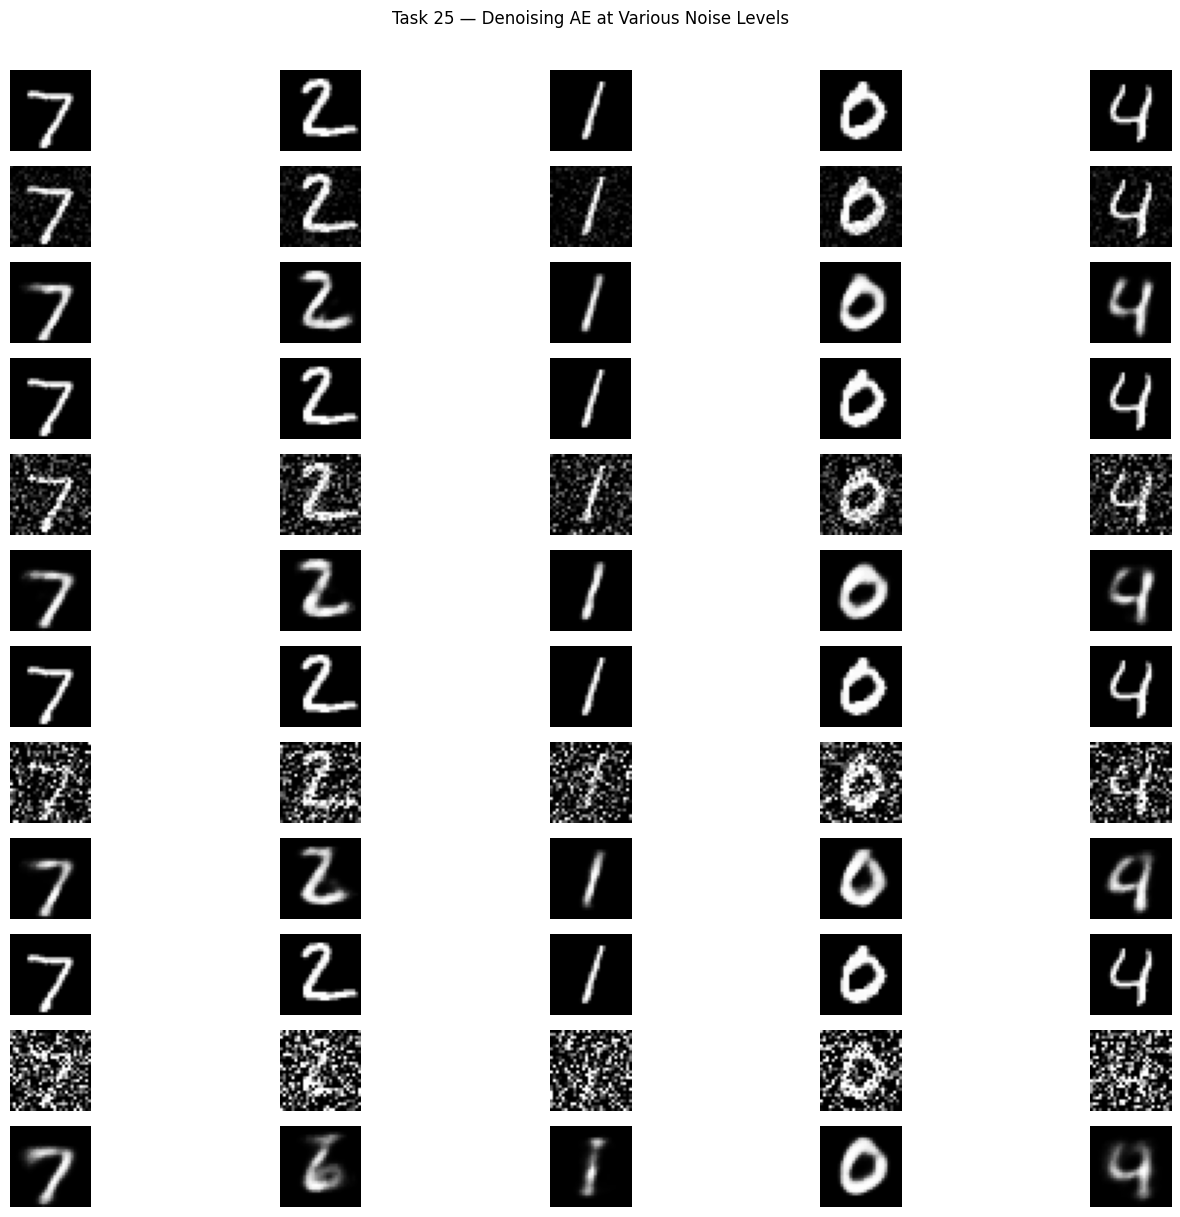

In [ ]:
print('\n=== Denoising AE — Reconstruction MSE vs. clean images ===')

n = 5
n_rows = 3 * len(noise_levels)  # original + noisy + denoised for each nf
plt.figure(figsize=(15, 3 * len(noise_levels)))
row_idx = 1

for nf in noise_levels:
    x_test_noisy = add_noise(x_test, nf)
    denoised = dae_models[nf].predict(x_test_noisy, verbose=0)
    mse = np.mean((x_test - denoised) ** 2)
    print(f'  Noise {nf:.1f} | MSE={mse:.5f}')

    for i in range(n):
        # Row 1: original
        plt.subplot(n_rows, n, row_idx * n + i + 1 - n)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel(f'NF={nf}\nOriginal', fontsize=8)
        plt.axis('off')

        # Row 2: noisy input
        plt.subplot(n_rows, n, row_idx * n + i + 1)
        plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel('Noisy', fontsize=8)
        plt.axis('off')

        # Row 3: denoised output
        plt.subplot(n_rows, n, row_idx * n + i + 1 + n)
        plt.imshow(denoised[i].reshape(28, 28), cmap='gray')
        if i == 0: plt.ylabel('Denoised', fontsize=8)
        plt.axis('off')

    row_idx += 3

plt.suptitle('Task 25 — Denoising AE at Various Noise Levels', y=1.01)
plt.tight_layout()
plt.show()

### Observations — Task 25

| Noise Factor | Noisy Image Quality | Denoised Quality | MSE |
|---|---|---|---|
| 0.1 | Slightly grainy | Near-perfect reconstruction | Very low |
| 0.3 | Moderately noisy | Clear digit, minor blur | Low |
| 0.5 | Heavily distorted | Digit still recognisable | Moderate |
| 0.7 | Extremely noisy | Basic shape preserved; fine detail lost | High |

**How much noise is acceptable?**
- Up to **noise_factor ≈ 0.4**, the denoising AE trained on that noise level produces recognisable, high-quality digits.
- At **noise_factor ≈ 0.5–0.6**, reconstruction becomes noticeably blurred but the class identity is still correct.
- Beyond **noise_factor ≈ 0.7**, the input is so corrupted that even with dedicated training the model struggles to recover fine structure.

**Conclusion**: A denoising AE is a powerful regulariser that forces the model to learn the underlying data manifold rather than noise. The practical noise tolerance depends on the task, but for MNIST a noise factor below 0.5 reliably yields acceptable reconstructions.